# TLS Traffic Anomaly Detection System Using Autoencoders with LSTM Enhancement
---

This notebook implements an advanced system for analyzing TLS (Transport Layer Security) traffic patterns and detecting anomalies through a hybrid neural network approach combining autoencoders with LSTM (Long Short-Term Memory) networks.

The system processes TLS records from JSON files and extracts two key types of features:

1. Static features including cipher suites (tls.ccs), which are processed by extracting the most frequent values and creating binary indicators
2. Sequential record features (tls.rec), which are now handled by LSTM layers to better capture temporal patterns in the data

## Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [124]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

## Setup and Imports

In [154]:
import math
import json
import glob
import os
import time
from datetime import datetime
from collections import Counter
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, Masking, Dropout

## Constants and Global Variables

In [146]:
# TLS Records processing constants
RECORD_SEQUENCE_SIZE = 25  # Maximum length for tls.rec sequences
REC_LATENT_DIM = 16   # Dimension for tls.rec latent representation
TLS_COLUMNS_NAMES = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Cipher Suite processing constants
TOP_N_CCS = 30  # Number of top cipher suites to track

# Global variables for model persistence
global_top_ccs = None
global_tls_rec_encoder = None
global_tls_rec_scaler = None

## Utility Functions
### Composite Number and Dimension Utilities
These functions help determine optimal dimensions for visualizing high-dimensional data as 2D images.

In [147]:
def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False


def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates


def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)


def get_padding_and_dim(x):
    """
    Find optimal dimensions for visualization by finding the nearest composite number
    that can be factored into dimensions with minimal difference.
    """
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1-d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1-d2) 
    return (val_x, val_d1, val_d2)

def resize_row(row, maxlen, pad_value=0):
    """Resize a row in the array to the specified length."""
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row

def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    """Convert a sample vector to a 2D image representation for visualization."""
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)

## TLS Records (tls.rec) Processing

These functions handle processing TLS record sequences using LSTM autoencoders for dimensionality reduction.

In [148]:
def pad_sequences(sequences, maxlen, padding='post', truncating='post', pad_value=0):
    """
    Pads sequences to the same length.
    """
    num_samples = len(sequences)
    padded_sequences = np.full((num_samples, maxlen), pad_value, dtype=float)
    
    for i, seq in enumerate(sequences):
        if not isinstance(seq, (list, np.ndarray)):
            continue
            
        seq = np.asarray(seq)
        if len(seq) == 0:
            continue
            
        if len(seq) >= maxlen:
            if truncating == 'pre':
                padded_sequences[i] = seq[-maxlen:]
            else:
                padded_sequences[i] = seq[:maxlen]
        else:
            if padding == 'pre':
                padded_sequences[i, -len(seq):] = seq
            else:
                padded_sequences[i, :len(seq)] = seq
                
    return padded_sequences

def normalize_tls_rec_data(data, method='standard'):
    """
    Normalize TLS record data.
    """
    original_shape = data.shape
    flattened = data.reshape(-1, 1)
    
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler(feature_range=(-1, 1))
    else:
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
    
    # Fit and transform
    normalized = scaler.fit_transform(flattened)
    
    # Reshape back
    normalized = normalized.reshape(original_shape)
    
    return normalized, scaler

def build_tls_rec_autoencoder(max_length=RECORD_SEQUENCE_SIZE, latent_dim=REC_LATENT_DIM):
    """
    Build an LSTM-based autoencoder for TLS record sequences.
    """
    # Input layer
    inputs = Input(shape=(max_length,))
    
    # Reshape for LSTM
    reshaped = tf.keras.layers.Reshape((max_length, 1))(inputs)
    
    # Add masking layer to handle variable length sequences
    masked = Masking(mask_value=0.0)(reshaped)
    
    # Encoder
    encoded = LSTM(64, return_sequences=True)(masked)
    encoded = LSTM(32)(encoded)
    encoded = Dense(latent_dim, activation='tanh')(encoded)
    
    # Decoder
    decoded = RepeatVector(max_length)(encoded)
    decoded = LSTM(32, return_sequences=True)(decoded)
    decoded = LSTM(64, return_sequences=True)(decoded)
    decoded = TimeDistributed(Dense(1))(decoded)
    
    # Flatten back to original shape
    output = tf.keras.layers.Reshape((max_length,))(decoded)
    
    # Create models
    lstm_autoencoder = Model(inputs, output)
    encoder = Model(inputs, encoded)
    
    # Compile the model
    lstm_autoencoder.compile(optimizer='adam', loss='mse')
    
    return lstm_autoencoder, encoder

def train_tls_rec_autoencoder(tls_rec_data, max_length=RECORD_SEQUENCE_SIZE, latent_dim=REC_LATENT_DIM, 
                              epochs=50, batch_size=32, validation_split=0.2, save_models=True):
    """
    Train the LSTM autoencoder on TLS record data.
    """
    # Filter out None or empty lists
    valid_sequences = [seq for seq in tls_rec_data if isinstance(seq, list) and len(seq) > 0]
    
    # Pad sequences
    padded_sequences = pad_sequences(valid_sequences, maxlen=max_length)
    
    # Normalize data
    normalized_data, scaler = normalize_tls_rec_data(padded_sequences, method='standard')
    
    # Build model
    lstm_autoencoder, encoder = build_tls_rec_autoencoder(max_length, latent_dim)
    
    # Print model summary
    lstm_autoencoder.summary()
    
    # Train model
    history = lstm_autoencoder.fit(
        normalized_data, normalized_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1
    )
    
    if save_models:
        # Save the models
        encoder_path, scaler_path = save_tls_rec_models(encoder, scaler, max_length, epochs, batch_size)
        print(f"Models saved: {encoder_path}, {scaler_path}")

    return lstm_autoencoder, encoder, scaler, history

def extract_tls_rec_features(tls_rec_data, encoder, scaler, max_length=RECORD_SEQUENCE_SIZE):
    """
    Extract latent features from TLS record data using the trained encoder.
    """
    # Filter out None or empty lists
    valid_sequences = [seq for seq in tls_rec_data if isinstance(seq, list) and len(seq) > 0]
    
    # Handle empty input
    if not valid_sequences:
        return np.zeros((len(tls_rec_data), REC_LATENT_DIM))
    
    # Pad sequences
    padded_sequences = pad_sequences(valid_sequences, maxlen=max_length)
    
    # Normalize data using the provided scaler
    original_shape = padded_sequences.shape
    flattened = padded_sequences.reshape(-1, 1)
    normalized = scaler.transform(flattened)
    normalized = normalized.reshape(original_shape)
    
    # Extract features using the encoder
    features = encoder.predict(normalized)
    
    # Create a mapping back to original indices
    result = np.zeros((len(tls_rec_data), REC_LATENT_DIM))
    valid_indices = [i for i, seq in enumerate(tls_rec_data) if isinstance(seq, list) and len(seq) > 0]
    
    for i, orig_idx in enumerate(valid_indices):
        result[orig_idx] = features[i]
    
    return result

def save_tls_rec_models(encoder, scaler, rec_length=20, epochs=50, batch_size=32, base_path="../models"):
    """
    Save trained TLS record encoder model and scaler for future use.
    """
    import os
    import pickle
    
    # Create the base directory if it doesn't exist
    os.makedirs(base_path, exist_ok=True)
    
    # Save the encoder model
    encoder_path = os.path.join(base_path, f"tls_rec_encoder_len={rec_length}_e={epochs}_bs={batch_size}.h5")
    encoder.save(encoder_path)
    
    # Save the scaler
    scaler_path = os.path.join(base_path, f"tls_rec_scaler_len={rec_length}_e={epochs}_bs={batch_size}.pkl")
    with open(scaler_path, 'wb') as file:
        pickle.dump(scaler, file)
    
    print(f"Model saved: {base_path}")
    return encoder_path, scaler_path

def load_tls_rec_models(rec_length=RECORD_SEQUENCE_SIZE, epochs=50, batch_size=32, base_path="../models"):
    """
    Load previously saved TLS record encoder model and scaler.
    """
    import os
    import pickle
    from tensorflow.keras.models import load_model
    
    # Define paths with the same naming convention as in save_tls_rec_models
    encoder_path = os.path.join(base_path, f"tls_rec_encoder_len={rec_length}_e={epochs}_bs={batch_size}.h5")
    scaler_path = os.path.join(base_path, f"tls_rec_scaler_len={rec_length}_e={epochs}_bs={batch_size}.pkl")
    
    # Check if both files exist
    if not os.path.exists(encoder_path) or not os.path.exists(scaler_path):
        return None, None
    
    # Load the encoder model
    encoder = load_model(encoder_path)
    
    # Load the scaler
    with open(scaler_path, 'rb') as file:
        scaler = pickle.load(file)
    
    print(f"Loaded models from: {encoder_path} and {scaler_path}")
    return encoder, scaler

## Cipher Suite (tls.ccs) Processing
Functions for handling TLS cipher suite information.

In [149]:
def find_top_ccs_values(df, top_n):
    """
    Find the most common cipher suite values in the dataset.
    Returns a list of the top N most common values.
    """
    all_ccs = []
    for ccs_list in df['tls.ccs'].dropna():
        if isinstance(ccs_list, list):
            all_ccs.extend(ccs_list)
    
    # Calculate the frequency of each CCS value
    ccs_counter = Counter(all_ccs)
    
    # Get the most common CCS values
    top_ccs = [ccs for ccs, _ in ccs_counter.most_common(top_n)]
    
    print(f"Top {top_n} cipher suites: {top_ccs}")
    return top_ccs

def create_ccs_features(row, top_ccs):
    """
    Create binary features for each cipher suite in the top_ccs list.
    Returns a list of 0s and 1s indicating presence/absence of each cipher suite.
    """
    if not isinstance(row, list):
        return [0] * len(top_ccs)
    
    # Create a binary feature for each cipher suite
    return [1 if ccs in row else 0 for ccs in top_ccs]

def initialize_global_top_ccs(top_ccs):
    """Initialize the global top CCS list for consistent feature extraction."""
    global global_top_ccs
    global_top_ccs = top_ccs
    print(f"Initialized global top CCS list with {len(global_top_ccs)} values")

## Data Loading and Feature Extraction

In [152]:
def load_json_files(json_files):
    """
    Load data from the specified collection of JSON files.
    Returns raw data as a DataFrame.
    """
    all_data = []
    # Open each file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            all_data.extend(data)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def extract_features(df, use_global_ccs=True, use_lstm_encoder=True, models_path="../models"):
    """
    Extract features from the raw dataset.
    
    This function processes:
    - Flow related columns: 'bs', 'ps', 'br', 'pr', 'td'
    - TLS handshake columns: 'tls.cver', 'tls.sver', 'tls.scs'
    - TLS record sizes: 'tls.rec'
    - CCS features: Binary indicators for the most common cipher suites
    
    Returns:
    - A DataFrame with the extracted features
    - The list of top CCS values used
    """
    global global_top_ccs, global_tls_rec_encoder, global_tls_rec_scaler
    
    # Determine which top CCS values to use
    if use_global_ccs and global_top_ccs is not None:
        top_ccs = global_top_ccs
        print(f"Using global top CCS list with {len(top_ccs)} values")
    else:
        top_ccs = find_top_ccs_values(df, top_n=TOP_N_CCS)
        # If this is the first time extracting features, store the values globally
        if global_top_ccs is None:
            initialize_global_top_ccs(top_ccs)
    
    # Create binary features for cipher suites
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    ccs_features = df['tls.ccs'].apply(lambda x: create_ccs_features(x, top_ccs))
    ccs_df = pd.DataFrame(ccs_features.tolist(), columns=ccs_column_names)
    
    # Process flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    print(f"Flow data: {flow_data}")
    
    # Process TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    print(f"TLS handshake data: {tls_data}")
    
    # Process TLS records based on configuration
    if use_lstm_encoder and 'tls.rec' in df.columns:
        # Try to load existing models if globals are None
        if global_tls_rec_encoder is None or global_tls_rec_scaler is None:
            # First attempt to load saved models
            encoder, scaler = load_tls_rec_models(
                rec_length=RECORD_SEQUENCE_SIZE, 
                epochs=50, 
                batch_size=16,
                base_path=models_path
            )
            
            if encoder is not None and scaler is not None:
                print("Loaded previously saved LSTM encoder and scaler")
                global_tls_rec_encoder = encoder
                global_tls_rec_scaler = scaler
            else:
                # If loading fails, train new models
                print("Training LSTM autoencoder for tls.rec features...")
                _, encoder, scaler, _ = train_tls_rec_autoencoder(
                    df['tls.rec'].values, 
                    max_length=RECORD_SEQUENCE_SIZE,
                    epochs=50,
                    batch_size=16,
                    save_models=True
                )
                global_tls_rec_encoder = encoder
                global_tls_rec_scaler = scaler
                print("LSTM autoencoder training complete")

        # Extract LSTM-encoded features
        tls_rec_features = extract_tls_rec_features(
            df['tls.rec'].values,
            global_tls_rec_encoder,
            global_tls_rec_scaler
        )
        print(f"Extracted LSTM-encoded features with shape: {tls_rec_features.shape}")
        
        # Create a DataFrame with the encoded features
        rec_columns = [f'tls.rec.encoded.{i}' for i in range(REC_LATENT_DIM)]
        records_data = pd.DataFrame(tls_rec_features, columns=rec_columns)
    else:
        # Use the original simple padding approach
        records_data = pd.DataFrame(
            pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), 
            columns=TLS_COLUMNS_NAMES
        )
    
    # Combine all features into a single dataset
    dataset = pd.concat([flow_data, tls_data, records_data, ccs_df], axis=1).fillna(0)
    return dataset, top_ccs

def fit_preprocessor(df, top_ccs, use_lstm_encoder=True):
    """
    Create and fit a preprocessing pipeline for the extracted features.
    
    This pipeline includes:
    - MinMaxScaler for numerical features
    - OneHotEncoder for categorical features
    
    Returns the fitted pipeline that can be used for transforming data.
    """
    # Define cipher suite columns
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    
    # Define transformers based on whether LSTM encoding is used
    if use_lstm_encoder:
        rec_columns = [f'tls.rec.encoded.{i}' for i in range(REC_LATENT_DIM)]
        
        # Create the column transformer
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
                ('num_tls_encoded', MinMaxScaler(), rec_columns),
                ('num_ccs', MinMaxScaler(), ccs_column_names), 
                ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
            ])
    else:
        # Create the column transformer for the original approach
        preprocessor = ColumnTransformer(
            transformers=[
                ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
                ('num_tls', MinMaxScaler(), TLS_COLUMNS_NAMES),
                ('num_ccs', MinMaxScaler(), ccs_column_names), 
                ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
            ])
    
    # Create the pipeline with the preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    
    # Fit the pipeline on the data
    pipeline.fit(df)
    return pipeline

Dataset shape=(14962, 28)
Using global top CCS list with 30 values
Flow data:             bs    ps        br    pr      td
0       1377.0   6.0    7607.0   9.0   0.221
1      11628.0  10.0    4676.0   9.0   4.470
2       1418.0   6.0    6495.0   7.0   0.060
3       2990.0  12.0    6951.0   7.0   0.544
4       1575.0   7.0   36879.0  16.0   0.048
...        ...   ...       ...   ...     ...
14957   2701.0   5.0  252401.0  35.0   0.057
14958   2862.0   7.0    5181.0   7.0   0.040
14959   5390.0  12.0    9718.0  13.0  25.673
14960   3717.0   9.0    5819.0   8.0   0.057
14961   3327.0   8.0    5117.0   8.0   0.058

[14962 rows x 5 columns]
TLS handshake data:       tls.cver tls.sver tls.scs
0       0x0303   0x0303  0x1301
1       0x0303   0x0303  0xc02b
2       0x0303   0x0303  0x1301
3       0x0303   0x0303  0x1301
4       0x0303   0x0303  0x1301
...        ...      ...     ...
14957   0x0303   0x0303  0x1302
14958   0x0303   0x0303  0x1301
14959   0x0303   0x0303  0x1301
14960   0x0303  

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_20          │ (None, 25, 1)     │          0 │ input_layer_26[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 25, 1)     │          0 │ reshape_20[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_10          │ (None, 25, 1)     │          0 │ reshape_20[0][0]  │
│ (Masking)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_10 (Any)        │ (None, 25)        │          0 │ not_equal_10[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_40 (LSTM)      │ (None, 25, 64)    │     16,896 │ masking_10[0][0], │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_41 (LSTM)      │ (None, 32)        │     12,416 │ lstm_40[0][0],    │
│                     │                   │            │ any_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 16)        │        528 │ lstm_41[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_10    │ (None, 25, 16)    │          0 │ dense_36[0][0]    │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_42 (LSTM)      │ (None, 25, 32)    │      6,272 │ repeat_vector_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_43 (LSTM)      │ (None, 25, 64)    │     24,832 │ lstm_42[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 25, 1)     │         65 │ lstm_43[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_21          │ (None, 25)        │          0 │ time_distributed… │
│ (Reshape)           │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,009 (238.32 KB)

 Trainable params: 61,009 (238.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - loss: 0.6283 - val_loss: 0.4268
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 26s 35ms/step - loss: 0.4270 - val_loss: 0.3597
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - loss: 0.3772 - val_loss: 0.3462
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - loss: 0.3697 - val_loss: 0.3166
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - loss: 0.3368 - val_loss: 0.2824
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 44s 57ms/step - loss: 0.3091 - val_loss: 0.2775
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - loss: 0.3209 - val_loss: 0.3113
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - loss: 0.2902 - val_loss: 0.2775
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.2817 - val_loss: 0.3009
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.2685 - val_loss: 0.2099
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.2405 - val_loss: 0.2260
Epoch 12/50
749/749 ━━━━━━━━━━

Model saved: ../models
Models saved: ../models/tls_rec_encoder_len=25_e=50_bs=16.h5, ../models/tls_rec_scaler_len=25_e=50_bs=16.pkl
LSTM autoencoder training complete
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Extracted LSTM-encoded features with shape: (14962, 16)
Normalized row of data:
[2.17753132e-03 2.21631206e-03 9.79934060e-05 8.92359175e-04
 6.24198375e-03 1.98623721e-01 6.16875319e-01 2.16901852e-01
 3.65547158e-01 6.11166429e-01 1.58054269e-01 4.17162315e-01
 8.95781040e-01 7.78211017e-01 7.95409578e-01 1.18428281e-01
 1.90746291e-01 7.20720574e-01 7.68317736e-01 6.74152137e-01
 7.78442430e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000

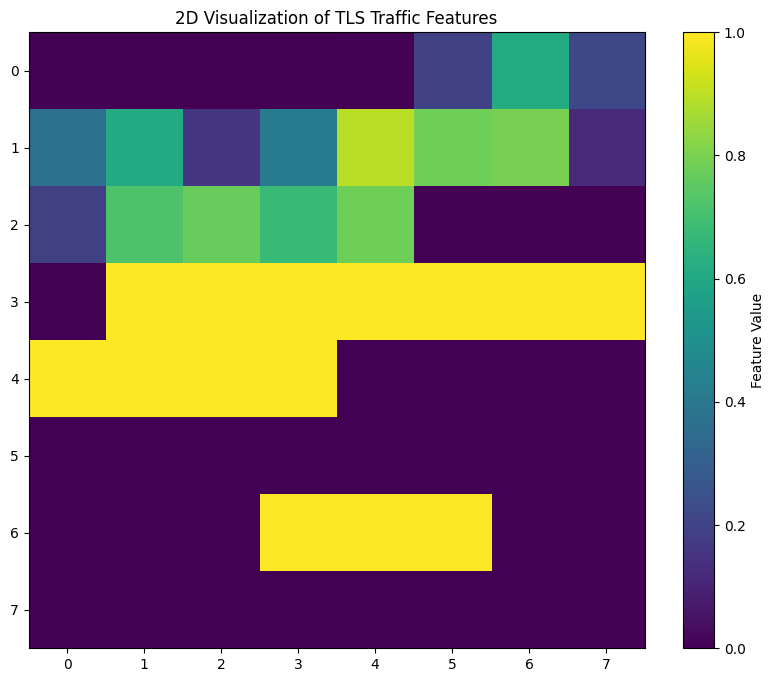

In [ ]:
# Load normal data (desktop application TLS traffic)
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'Dataset shape={raw_df.shape}')

# Extract features from the raw data
input_df, top_ccs = extract_features(raw_df, use_lstm_encoder=True)

# Store top CCS values globally for consistent feature extraction
global_top_ccs = top_ccs

# Create and fit the preprocessing pipeline
pipeline = fit_preprocessor(input_df, top_ccs)

# Transform the data using the pipeline
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])
print(f'Dataset shape={normal_df.shape}')

# Prepare for visualization
row_len = normal_df.shape[1]
(new_row_len, dim_x, dim_y) = get_padding_and_dim(row_len)
image_pad = new_row_len - row_len
print(f"Visualization adjustment: {row_len} -> {new_row_len} (+ {image_pad}) [{dim_x} x {dim_y}]")

# Create an image representation of the first sample
sample_image = make_image_from_sample(normal_df[0], image_pad, dim_x, dim_y)

# Visualize the sample
plt.figure(figsize=(10, 8))
plt.imshow(sample_image, cmap='gray')
plt.colorbar(label='Feature Value')
plt.title('2D Visualization of TLS Traffic Features')
plt.show()

## Data Loading and Feature Extraction

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

In [163]:
import keras
from keras import ops
from keras import layers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

class Autoencoder(Model):
  """
  Autoencoder model for anomaly detection in TLS traffic data.
  """
  def __init__(self, latent_dim, input_dim):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.input_dim = input_dim
    
    self.encoder = tf.keras.Sequential([
      layers.Dense(latent_dim, activation='relu')
    ])
    
    self.decoder = tf.keras.Sequential([
      layers.Dense(input_dim, activation='sigmoid')
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded
    
  def encode(self, x):
    return self.encoder(x)
    
  def decode(self, x):
    return self.decoder(x)
  
def train_autoencoder(x_train, x_test, input_dim, latent_dim=6, epochs=50, batch_size=16):
    """
    Train an autoencoder for anomaly detection.
    
    Parameters:
    -----------
    x_train : numpy array
        Training data
    x_test : numpy array
        Testing data
    input_dim : int
        Input dimension
    latent_dim : int
        Dimension of the latent space
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    autoencoder : Autoencoder
        Trained autoencoder model
    history : History
        Training history
    training_time : float
        Time taken for training
    """
    # Autoencoder model
    autoencoder = Autoencoder(latent_dim, input_dim)
    
    # Compile and train the autoencoder
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    
    # Start training and measure time
    start_time = time.time()
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=1
    )
    training_time = time.time() - start_time
    
    return autoencoder, history, training_time

def evaluate_autoencoder(autoencoder, x_test):
    """
    Evaluate the autoencoder by calculating reconstruction errors.
    
    Parameters:
    -----------
    autoencoder : Autoencoder
        Trained autoencoder model
    x_test : numpy array
        Test data
        
    Returns:
    --------
    encoded_imgs : numpy array
        Encoded representations of test data
    decoded_imgs : numpy array
        Reconstructed test data
    reconstruction_errors : numpy array
        Reconstruction errors for each test sample
    """
    # Encode and decode the test data
    encoded_imgs = autoencoder.encode(x_test)
    decoded_imgs = autoencoder.decode(encoded_imgs)
    
    # Calculate reconstruction errors
    reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

    # Calculate statistics
    avg_error = np.mean(reconstruction_errors)
    max_error = np.max(reconstruction_errors)
    min_error = np.min(reconstruction_errors)
    
    print(f"Average={avg_error:.6f}, Max={max_error:.6f}, Min={min_error:.6f} reconstruction errors.")
    
    return encoded_imgs, decoded_imgs, reconstruction_errors

def visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, method_name, make_image_func):
  """
  Visualize original and reconstructed samples with the worst reconstruction errors.
  
  Parameters:
  -----------
  x_test : numpy array
      Original test data
  decoded_imgs : numpy array
      Reconstructed test data
  reconstruction_errors : numpy array
      Reconstruction errors for each test sample
  method_name : str
      Name of the method used for visualization title
  make_image_func : function
      Function to convert a sample to a 2D image
  """
  # Get the 20 samples with the worst reconstruction errors
  worst20 = np.argsort(reconstruction_errors)[-20:][::-1]
  
  n = 20  # Number of samples to display
  i = 0
  
  print(f"Worst reconstructed ({method_name}):")
  plt.figure(figsize=(20, 4))
  for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_func(original, image_pad, dim_x, dim_y) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_func(reconstructed, image_pad, dim_x, dim_y) 
    
    # Original image
    plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i += 1
  
  plt.suptitle(f"{method_name} Method Reconstructions")
  plt.tight_layout()
  plt.subplots_adjust(top=0.85)
  plt.show()

Training dataset shape: (11969, 61)
Testing dataset shape (normal): (2993, 61)
Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 2s 936us/step - loss: 0.4201 - val_loss: 0.2139
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - loss: 0.2097 - val_loss: 0.1961
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 758us/step - loss: 0.1936 - val_loss: 0.1814
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 757us/step - loss: 0.1784 - val_loss: 0.1712
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - loss: 0.1698 - val_loss: 0.1658
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 722us/step - loss: 0.1652 - val_loss: 0.1625
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 885us/step - loss: 0.1621 - val_loss: 0.1606
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - loss: 0.1602 - val_loss: 0.1590
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 0.1583 - val_loss: 0.1578
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - loss: 0.1577 - val_loss: 0.1570
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━

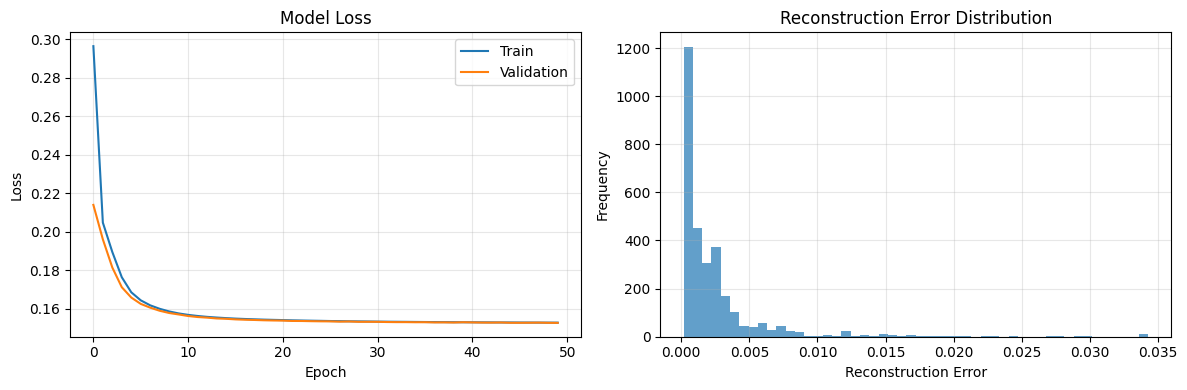

Worst reconstructed (Autoencoder):


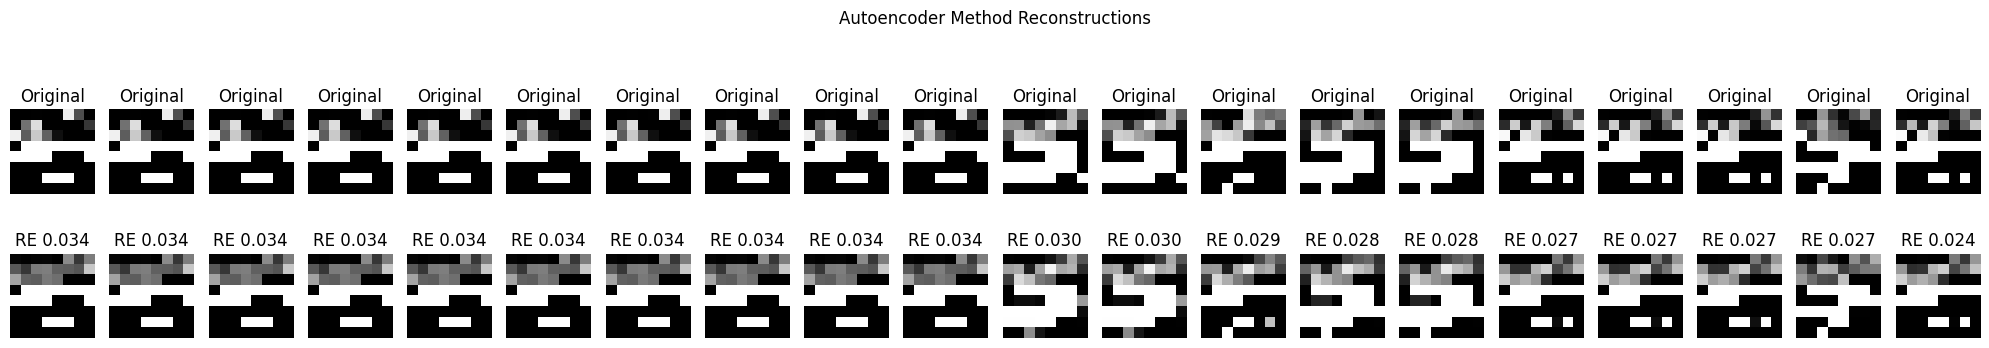

In [164]:
# Set the size of the latent space
LATENT_SPACE_SIZE = 6

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Training dataset shape: {x_train.shape}')
print(f'Testing dataset shape (normal): {x_test.shape}')

# Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Train the autoencoder
autoencoder, history, training_time = train_autoencoder(
    x_train, 
    x_test, 
    input_dim=input_dim, 
    latent_dim=encoding_dim, 
    epochs=50, 
    batch_size=16
)
print(f"Training time: {training_time:.2f} seconds")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid(True, alpha=0.3)

# Evaluate the autoencoder on test data
encoded_imgs, decoded_imgs, reconstruction_errors = evaluate_autoencoder(autoencoder, x_test)

# Plot error distribution
plt.subplot(1, 2, 2)
plt.hist(reconstruction_errors, bins=50, alpha=0.7)
plt.title('Reconstruction Error Distribution')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize the reconstructions
visualize_reconstructions(x_test, decoded_imgs, reconstruction_errors, "Autoencoder", make_image_from_sample)

## Dataset Testing Function for Anomaly Detection
The following function allows testing different datasets using the trained autoencoder.

In [168]:
def test_dataset(json_files, top_ccs, dataset_name="Unnamed Dataset", export_results=False):
    """
    Test a TLS dataset and print detailed results in English.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    top_ccs : list
        List of top CCS values used during training
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    """
    # Start timing
    start_time = time.time()
    
    # Load and process data
    raw_test_df = load_json_files(json_files)
    
    # Find this dataset's own top CCS values (for analysis purposes)
    dataset_top_ccs = find_top_ccs_values(raw_test_df, top_n=TOP_N_CCS)
    print(f"Top 30 cipher suites in {dataset_name}: {dataset_top_ccs}")
    
    # Compare with training dataset's CCS values
    common_ccs = set(dataset_top_ccs) & set(top_ccs)
    unique_ccs = set(dataset_top_ccs) - set(top_ccs)
    print(f"CCS values in common with training data: {len(common_ccs)}")
    print(f"CCS values unique to this dataset: {len(unique_ccs)}")
    if unique_ccs:
        print(f"Unique CCS values: {', '.join(list(unique_ccs)[:10])}")
    
    # Use training top CCS for feature extraction to ensure model compatibility
    input_test_df, _ = extract_features(raw_test_df, use_global_ccs=True, use_lstm_encoder=True)
    
    # Transform data using the pipeline
    test_df = pipeline.transform(input_test_df)
    print(f"Processed dataset shape: {test_df.shape} ({test_df.shape[0]} samples with {test_df.shape[1]} features)")
    
    # Encode and decode using the autoencoder
    encoded_test = autoencoder.encode(test_df)
    decoded_test = autoencoder.decode(encoded_test)
        
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original, image_pad, dim_x, dim_y)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed, image_pad, dim_x, dim_y)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_ccs': dataset_top_ccs
    }

Using global top CCS list with 30 values
Flow data:             bs    ps        br    pr      td
0       1377.0   6.0    7607.0   9.0   0.221
1      11628.0  10.0    4676.0   9.0   4.470
2       1418.0   6.0    6495.0   7.0   0.060
3       2990.0  12.0    6951.0   7.0   0.544
4       1575.0   7.0   36879.0  16.0   0.048
...        ...   ...       ...   ...     ...
14957   2701.0   5.0  252401.0  35.0   0.057
14958   2862.0   7.0    5181.0   7.0   0.040
14959   5390.0  12.0    9718.0  13.0  25.673
14960   3717.0   9.0    5819.0   8.0   0.057
14961   3327.0   8.0    5117.0   8.0   0.058

[14962 rows x 5 columns]
TLS handshake data:       tls.cver tls.sver tls.scs
0       0x0303   0x0303  0x1301
1       0x0303   0x0303  0xc02b
2       0x0303   0x0303  0x1301
3       0x0303   0x0303  0x1301
4       0x0303   0x0303  0x1301
...        ...      ...     ...
14957   0x0303   0x0303  0x1302
14958   0x0303   0x0303  0x1301
14959   0x0303   0x0303  0x1301
14960   0x0303   0x0303  0x1301
14961   0x

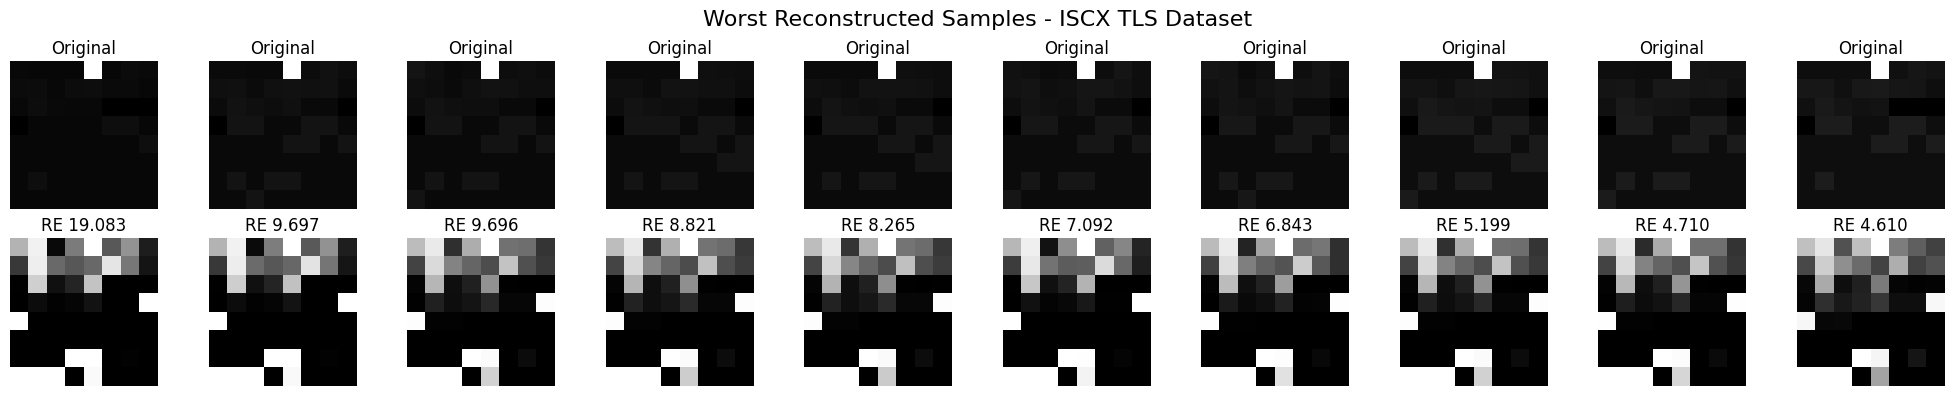


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 61
Average reconstruction error: 0.326862
Processing time: 0.31 seconds
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
Top 30 cipher suites in Mobile TLS Dataset: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
CCS values in common with training data: 27
CCS values unique to this dataset: 3
Unique CCS values: C008, CCAA, C012
Using global top CCS list with 30 values
Flow data:           bs    ps        br    pr      td
0      994.0   3.0   13793.0  12.0   0.089
1     2301.0   4.0     916.0   4.

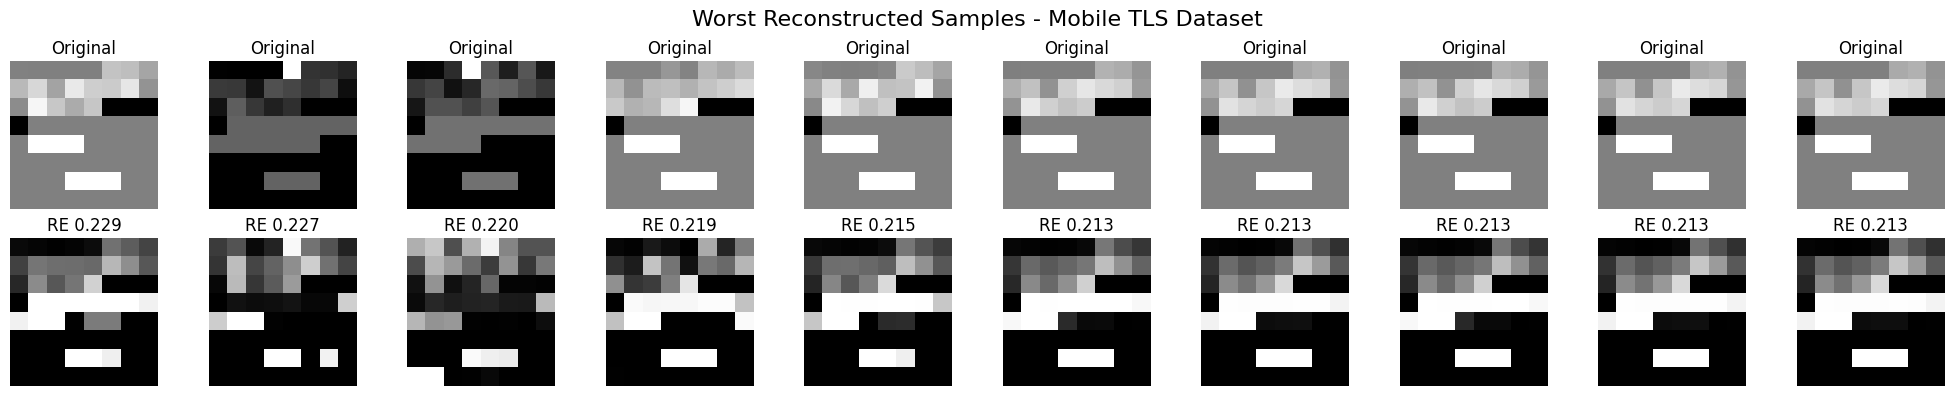


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 61
Average reconstruction error: 0.019759
Processing time: 1.10 seconds
Top 30 cipher suites: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
Top 30 cipher suites in Windows TLS Dataset: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
CCS values in common with training data: 30
CCS values unique to this dataset: 0
Using global top CCS list with 30 values
Flow data:            bs   ps      br   pr     td
0      2702.0  4.0  7275.0  7.0  0.637
1      2235.0  4.0  9039.0  6.0  0.653
2      1668.0  3.0  5338.0  4.0  0.

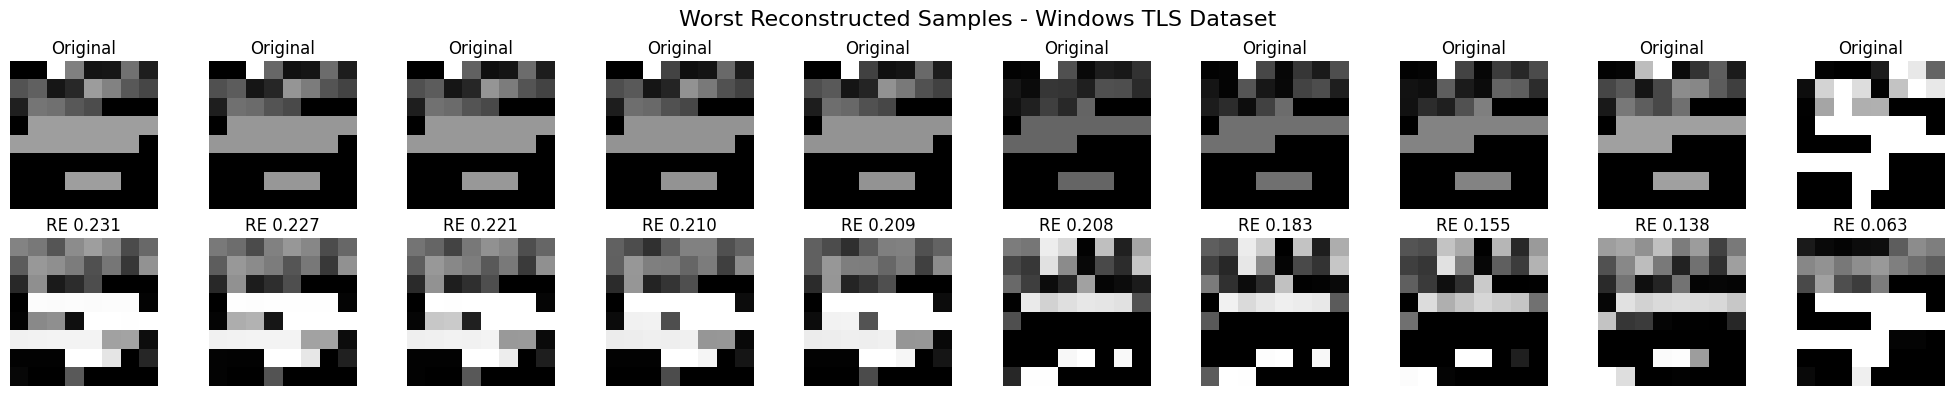


PERFORMANCE SUMMARY:
Dataset: Windows TLS Dataset
Number of samples: 15047
Number of features: 61
Average reconstruction error: 0.002593
Processing time: 4.29 seconds
Top 30 cipher suites: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
Top 30 cipher suites in CIC-AA Normal TLS Dataset: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0008, 0009, C007, 0003, 0005, CC14, 0006, CC13, 0004, C011
Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0       831.0   6.0  2

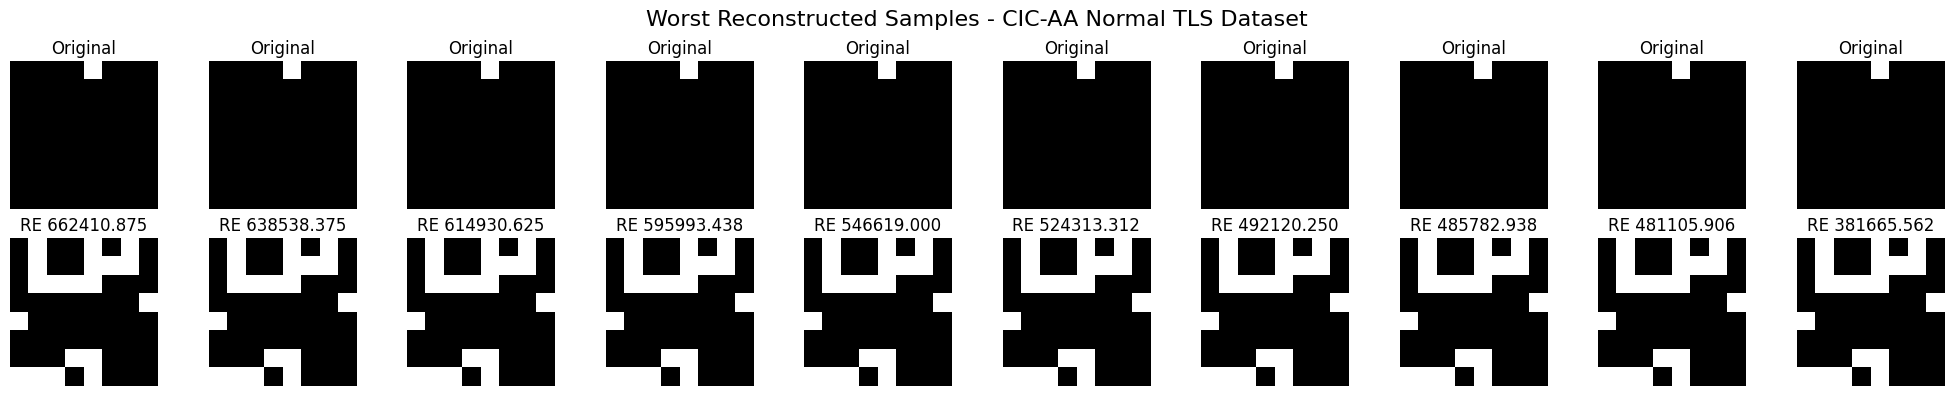


PERFORMANCE SUMMARY:
Dataset: CIC-AA Normal TLS Dataset
Number of samples: 31179
Number of features: 61
Average reconstruction error: 403.900330
Processing time: 6.48 seconds
Top 30 cipher suites: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
Top 30 cipher suites in CIC-AA Malware TLS Dataset: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0008, 0009, C007, 0003, 0005, CC14, 0006, CC13, 0004, C011
Using global top CCS list with 30 values
Flow data:          bs    ps       br    pr       td
0    1945.0   

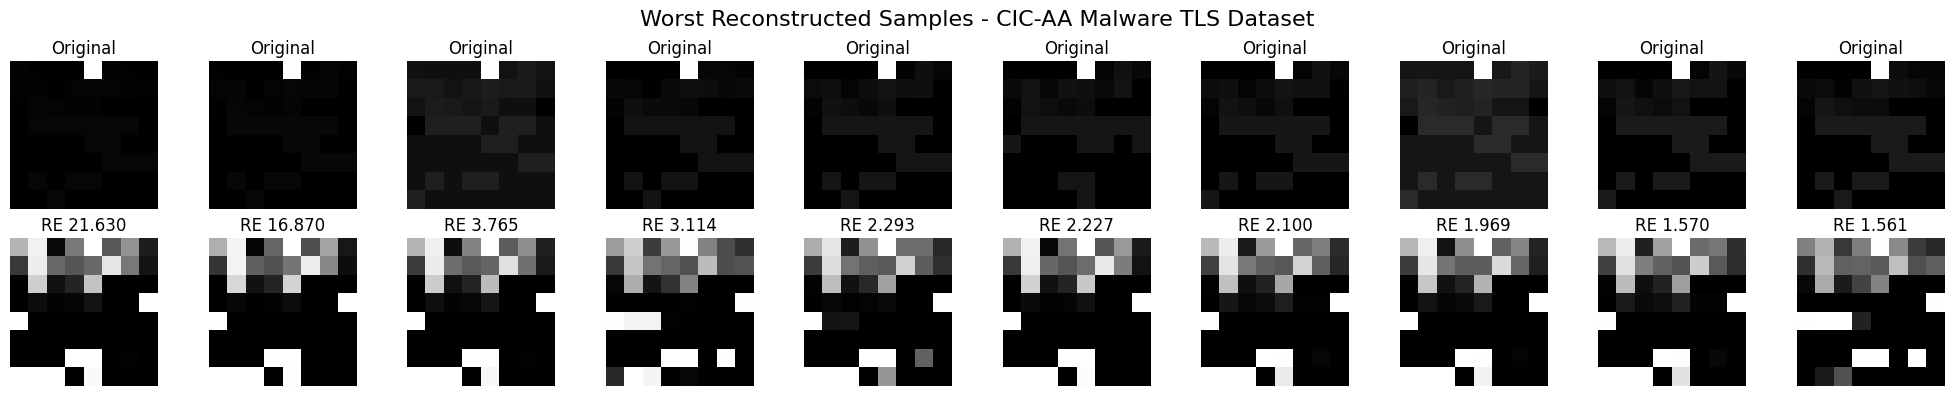


PERFORMANCE SUMMARY:
Dataset: CIC-AA Malware TLS Dataset
Number of samples: 462
Number of features: 61
Average reconstruction error: 0.393123
Processing time: 0.26 seconds
Top 30 cipher suites: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
Top 30 cipher suites in CIC-AA Adware TLS Dataset: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: C007, C022, 00A3, 0005, CC14, C021, CC13, 0004, C011, CC15
Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0      2607.0   5

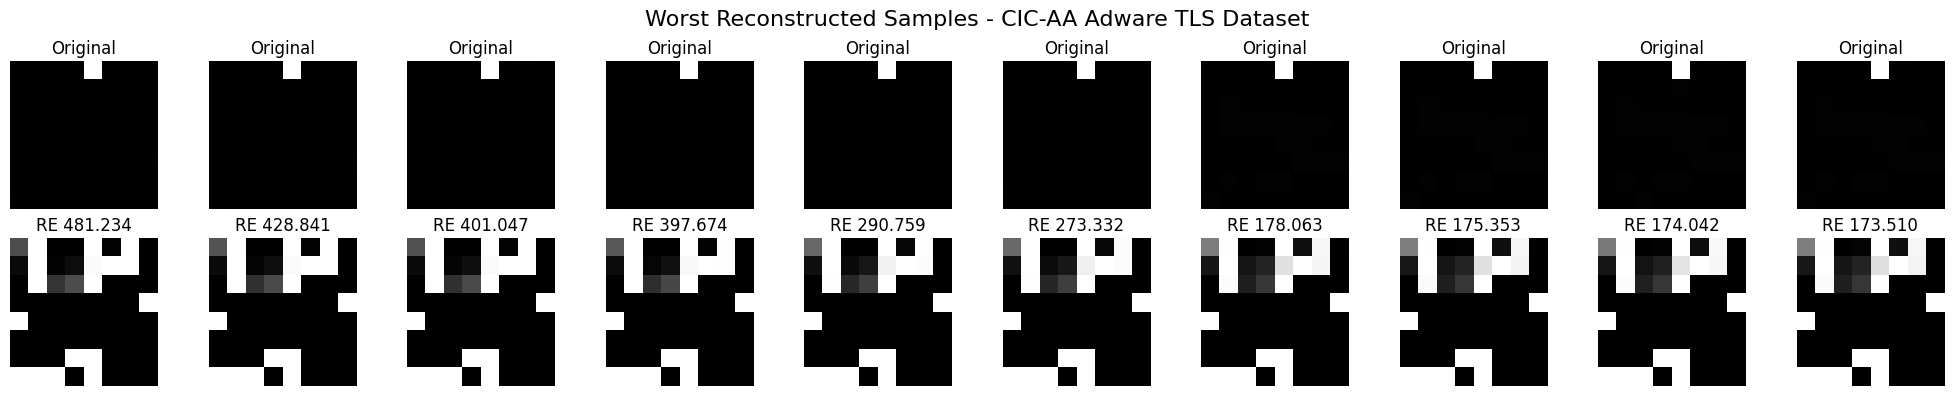


PERFORMANCE SUMMARY:
Dataset: CIC-AA Adware TLS Dataset
Number of samples: 7122
Number of features: 61
Average reconstruction error: 0.972785
Processing time: 1.28 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error     Max Error  Min Error
          ISCX TLS Dataset     1112        61   0.326862     19.083012   0.006717
        Mobile TLS Dataset     5616        61   0.019759      0.229075   0.000099
       Windows TLS Dataset    15047        61   0.002593      0.230663   0.000155
 CIC-AA Normal TLS Dataset    31179        61 403.900330 662410.875000   0.013652
CIC-AA Malware TLS Dataset      462        61   0.393123     21.630116   0.029357
 CIC-AA Adware TLS Dataset     7122        61   0.972785    481.233948   0.018242


In [169]:
# Initialize results dictionary
results = {}

# Load normal data and extract features
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
input_df, top_ccs = extract_features(raw_df)

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

# Test Windows dataset
results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Windows TLS Dataset",
    export_results=True
)

# Test cic-aa.normal datasets
results['cic-aa.normal'] = test_dataset(
    glob.glob("../datasets/cic-aa.normal.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Normal TLS Dataset",
    export_results=True
)

# Test cic-aa.malware datasets
results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Malware TLS Dataset",
    export_results=True
)

# Test cic-aa.adware datasets
results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="CIC-AA Adware TLS Dataset",
    export_results=True
)

# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)


In [170]:
# Define constants for dataset labels
NORMAL_LABEL = 'Normal dataset (Desktop.tls)'
MALICIOUS_LABEL = 'Malicious dataset (Adware.tls)'

# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.malware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/iscx.tls/*.json"))

input_abnormal_df, _ = extract_features(abnormal_raw_df, use_global_ccs=True)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = autoencoder.encode(abnormal_df)
decoded_abnormal = autoencoder.decode(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': [MALICIOUS_LABEL] * len(errors_abnormal)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': [NORMAL_LABEL] * len(reconstruction_errors)
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

Using global top CCS list with 30 values
Flow data:            bs    ps      br    pr       td
0      2607.0   5.0  3396.0   4.0    0.498
1      2607.0   5.0  3395.0   4.0    0.432
2      2607.0   5.0  3395.0   4.0    0.517
3      2607.0   5.0  3369.0   4.0    0.476
4      2532.0   5.0   625.0   2.0    0.375
...       ...   ...     ...   ...      ...
7117   1343.0   4.0  3192.0   6.0  300.166
7118   1453.0   4.0  3099.0   5.0  300.185
7119  13582.0  17.0  8916.0  13.0  301.379
7120   1743.0   4.0  4940.0   6.0    0.195
7121   1063.0   4.0  2929.0   4.0    0.202

[7122 rows x 5 columns]
TLS handshake data:      tls.cver tls.sver tls.scs
0      0x0303   0x0303  0xc02f
1      0x0303   0x0303  0xc02f
2      0x0303   0x0303  0xc02f
3      0x0303   0x0303  0xc02f
4      0x0303   0x0303  0xc02f
...       ...      ...     ...
7117   0x0303   0x0303  0xc02f
7118   0x0303   0x0303  0xc02f
7119   0x0303   0x0303  0xc02f
7120   0x0303   0x0303  0xc02f
7121   0x0303   0x0303  0xc02f

[7122 rows x 3

,error,y_true
0,0.000585,Normal dataset (Desktop.tls)
1,0.004960,Normal dataset (Desktop.tls)
2,0.000198,Normal dataset (Desktop.tls)
3,0.001912,Normal dataset (Desktop.tls)
4,0.002730,Normal dataset (Desktop.tls)


In [171]:
def thresholdTuning(df, iterations):
    
    # Create a mapping of string labels to numeric values for classification metrics
    label_mapping = {
        NORMAL_LABEL: 0,
        MALICIOUS_LABEL: 1
    }
    
    # Convert string labels to numeric for classification report
    y_true_numeric = df['y_true'].map(label_mapping)
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = (df['error'] > thresh_value).astype(int)  # Convert boolean to int
        cr = classification_report(y_true_numeric, preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)

thresh_df = thresholdTuning(recons_df, 100)

threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold: 0.0002	Accuracy: 0.704		Precision: 0.852	Recall Score: 0.500
Threshold: 0.0002	Accuracy: 0.714		Precision: 0.856	Recall Score: 0.517
Threshold: 0.0003	Accuracy: 0.724		Precision: 0.859	Recall Score: 0.534
Threshold: 0.0003	Accuracy: 0.734		Precision: 0.863	Recall Score: 0.551
Threshold: 0.0003	Accuracy: 0.744		Precision: 0.867	Recall Score: 0.568
Threshold: 0.0004	Accuracy: 0.754		Precision: 0.871	Recall Score: 0.585
Threshold: 0.0005	Accuracy: 0.764		Precision: 0.875	Recall Score: 0.601
Threshold: 0.0005	Accuracy: 0.774		Precision: 0.879	Recall Score: 0.618
Threshold: 0.0006	Accuracy: 0.784		Precision: 0.883	Recall Score: 0.635
Threshold: 0.0006	Accuracy: 0.794		Precision: 0.887	Recall Score: 0.652
Threshold: 0.0007	Accuracy: 0.804		Precision: 0.891	Recall Score: 0.669
Threshold: 0.0008	Accuracy: 0.814		Precision: 0.896	Recall Score: 0.686
Threshold: 0.0009	Accuracy: 0.824		Precision: 0.900	Recall Score: 0.703
Threshold: 0.0010	Accuracy: 0.834		Precision: 0.905	Recall Score

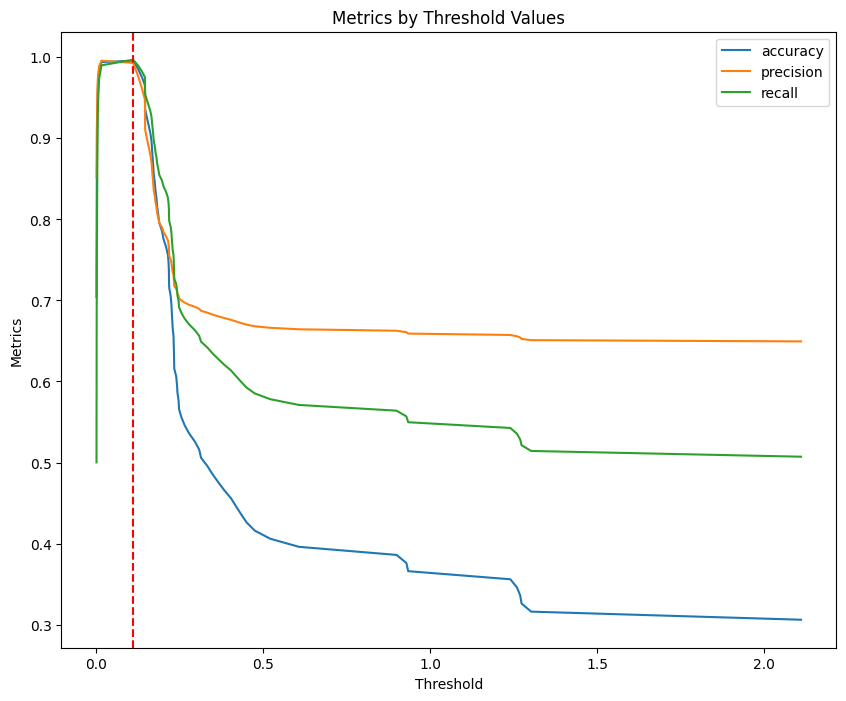

In [172]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

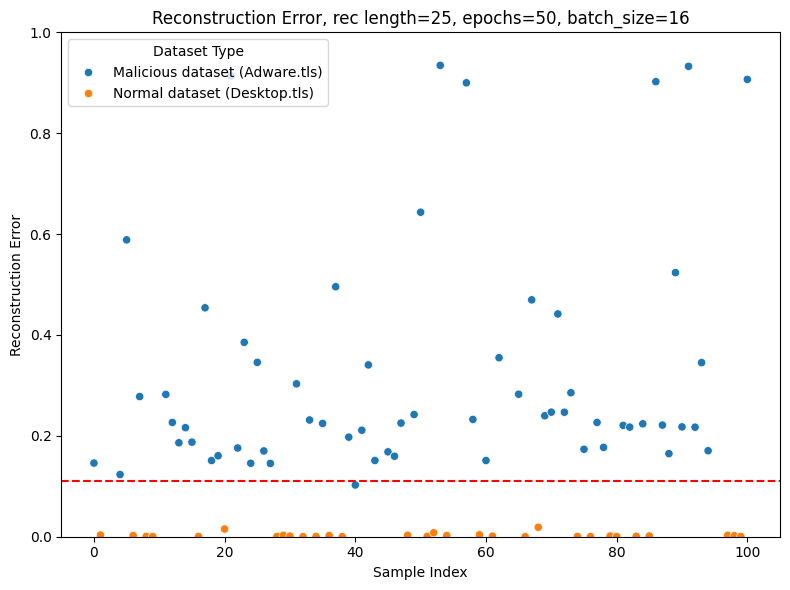

In [173]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 1)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title(f'Reconstruction Error, rec length={RECORD_SEQUENCE_SIZE}, epochs=50, batch_size=16')
plt.legend(title='Dataset Type')
plt.tight_layout()
plt.show()